In [87]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt

In [88]:
# Чтение и подготовка данных (как в исходном коде)
df = pd.read_csv('hw_2/train_data.csv')
display(df)

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,174430.0,Gloomhaven,2017.0,1,4,120,14,42055,"8,79",1,"3,86",68323.0,"Action Queue, Action Retrieval, Campaign / Bat...","Strategy Games, Thematic Games"
1,224517.0,Brass: Birmingham,2018.0,2,4,120,14,19217,"8,66",3,"3,91",28785.0,"Hand Management, Income, Loans, Market, Networ...",Strategy Games
2,167791.0,Terraforming Mars,2016.0,1,5,120,12,64864,"8,43",4,"3,24",87099.0,"Card Drafting, Drafting, End Game Bonuses, Han...",Strategy Games
3,233078.0,Twilight Imperium: Fourth Edition,2017.0,3,6,480,14,13468,"8,70",5,"4,22",16831.0,"Action Drafting, Area Majority / Influence, Ar...","Strategy Games, Thematic Games"
4,291457.0,Gloomhaven: Jaws of the Lion,2020.0,1,4,120,14,8392,"8,87",6,"3,55",21609.0,"Action Queue, Campaign / Battle Card Driven, C...","Strategy Games, Thematic Games"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15252,1410.0,Trouble,1965.0,2,4,45,4,3255,"3,79",20339,"1,05",4962.0,Roll / Spin and Move,Children's Games
15253,16398.0,War,0.0,2,2,30,4,1340,"2,28",20340,1,427.0,NaN,Children's Games
15254,5048.0,Candy Land,1949.0,2,4,30,3,4006,"3,18",20342,"1,08",5788.0,Roll / Spin and Move,Children's Games
15255,5432.0,Chutes and Ladders,-200.0,2,6,30,3,3783,"2,86",20343,"1,02",4400.0,"Dice Rolling, Grid Movement, Race, Roll / Spin...",Children's Games


In [89]:

df_nan = df.loc[:, df.isnull().any()]
df_nan.isnull().sum() / len(df_nan) * 100

df = df.drop(['Domains', 'Mechanics', 'ID', 'Name'], axis=1)
df['Owned Users'].fillna(df['Owned Users'].mean(), inplace=True)
df = df.dropna(axis=0)

df['Complexity Average'] = df['Complexity Average'].replace(',', '.', regex=True).astype(float)
df['Rating Average'] = df['Rating Average'].replace(',', '.', regex=True).astype(float)
df.describe()

df.loc[df['Min Players'] == 0, 'Min Players'] = 1
df.loc[df['Max Players'] == 0, 'Max Players'] = df['Min Players']

df[df['Min Players'] == 0]


/tmp/ipykernel_6329/177936422.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Owned Users'].fillna(df['Owned Users'].mean(), inplace=True)


,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,Rating Average,BGG Rank,Complexity Average,Owned Users


In [90]:
X = df.drop(['Rating Average'], axis=1)
Y = df['Rating Average']

std = StandardScaler()
X_std = std.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=X.columns)

mmsc = MinMaxScaler()
X_norm = mmsc.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y, test_size=0.15, random_state=42)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Test dataset size: {X_test.shape}, {y_test.shape}')


Train dataset size: (12954, 9), (12954,)
Test dataset size: (2286, 9), (2286,)


In [91]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

# Создание DataLoader для мини-батчей
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [92]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(RegressionNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 8)
        self.layer2 = nn.Linear(8, 8)
        self.layer3 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

In [ ]:
# Инициализация модели
input_dim = X_train.shape[1]
model = RegressionNN(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Обучение модели
num_epochs = 75
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
    
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

Epoch [20/75], Train Loss: 0.4110, Test Loss: 0.3837
Epoch [40/75], Train Loss: 0.2849, Test Loss: 0.3103
Epoch [60/75], Train Loss: 0.2505, Test Loss: 0.2682


In [94]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred = y_pred_tensor.numpy().flatten()
    y_test_np = y_test_tensor.numpy().flatten()

print("MAE:", metrics.mean_absolute_error(y_test_np, y_pred))
print("MSE:", metrics.mean_squared_error(y_test_np, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test_np, y_pred)))
print("R2 Score:", metrics.r2_score(y_test_np, y_pred))

MAE: 0.33940306305885315
MSE: 0.23817914724349976
RMSE: 0.4880360101913585
R2 Score: 0.7245899438858032


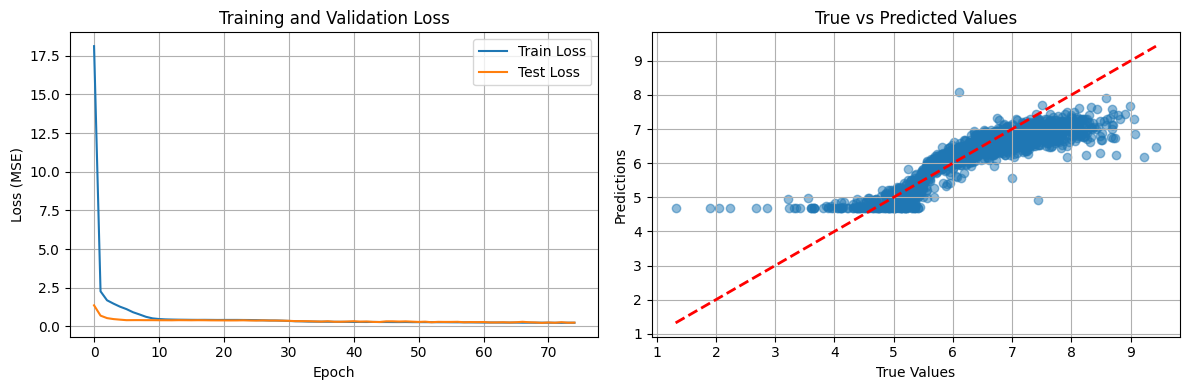

In [95]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_np, y_pred, alpha=0.5)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values')
plt.grid(True)

plt.tight_layout()
plt.show()

In [120]:
feature_importance = np.abs(model.layer1.weight.detach().numpy()).mean(axis=0)
feature_names = X.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Важность признаков (на основе среднего веса в первом слое):")
print("="*60)
print(importance_df)

Важность признаков (на основе среднего веса в первом слое):
              feature  importance
5         Users Rated    1.665209
8         Owned Users    1.152627
3           Play Time    0.908083
6            BGG Rank    0.767971
0      Year Published    0.232965
1         Min Players    0.138274
7  Complexity Average    0.121269
2         Max Players    0.048034
4             Min Age    0.043584


In [97]:
df_ts = pd.read_csv('hw_2/test_data.csv')
df_ts

,ID,Name,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users,Mechanics,Domains
0,161936.0,Pandemic Legacy: Season 1,2015.0,2,4,60,13,41643,2,"2,84",65294.0,"Action Points, Cooperative Game, Hand Manageme...","Strategy Games, Thematic Games"
1,12333.0,Twilight Struggle,2005.0,2,2,180,13,40814,10,"3,59",56219.0,"Action/Event, Advantage Token, Area Majority /...","Strategy Games, Wargames"
2,115746.0,War of the Ring: Second Edition,2012.0,2,4,180,13,13725,12,"4,14",22281.0,"Area Majority / Influence, Area Movement, Camp...","Thematic Games, Wargames"
3,169786.0,Scythe,2016.0,1,5,115,14,57871,14,"3,41",75640.0,"Area Majority / Influence, Card Play Conflict ...",Strategy Games
4,28720.0,Brass: Lancashire,2007.0,2,4,120,14,19400,19,"3,86",25429.0,"Hand Management, Income, Loans, Network and Ro...",Strategy Games
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5081,6932.0,Hi Ho! Cherry-O,1960.0,2,4,10,3,1035,20325,"1,03",1691.0,"Cooperative Game, Roll / Spin and Move",Children's Games
5082,3510.0,Battle of the Sexes,1997.0,2,8,45,12,1090,20328,"1,08",1987.0,Team-Based Game,Party Games
5083,5895.0,Hungry Hungry Hippos,1978.0,2,4,10,4,2361,20330,"1,05",2568.0,NaN,Children's Games
5084,2679.0,Mouse Trap,1963.0,2,4,30,6,2693,20333,"1,11",3408.0,Roll / Spin and Move,Children's Games


In [98]:
df_ts = df_ts.drop(['Domains', 'Mechanics', 'ID', 'Name'], axis=1)
df_ts['Owned Users'].fillna(df_ts['Owned Users'].mean(), inplace=True)


/tmp/ipykernel_6329/4225324966.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_ts['Owned Users'].fillna(df_ts['Owned Users'].mean(), inplace=True)


0       65294.0
1       56219.0
2       22281.0
3       75640.0
4       25429.0
         ...   
5081     1691.0
5082     1987.0
5083     2568.0
5084     3408.0
5085     1533.0
Name: Owned Users, Length: 5086, dtype: float64

In [99]:
df_ts['Complexity Average'] = df_ts['Complexity Average'].replace(',', '.', regex=True).astype(float)
# df_ts = df_ts[df_ts['Max Players'] >= df_ts['Min Players']]
# df_ts = df_ts[df_ts['Min Players'] > 0]
# df_ts = df_ts[df_ts['Play Time'] > 0]
# df_ts = df_ts[df_ts['Year Published'] > 1900]
df_ts.loc[df_ts['Min Players'] == 0, 'Min Players'] = 1
df_ts.loc[df_ts['Max Players'] == 0, 'Max Players'] = df_ts['Min Players']

df_ts[df_ts['Min Players'] == 0]

# df_ts.loc[df_ts['Play Time'] == 0, 'Play Time'] = 1

df_ts.describe()

,Year Published,Min Players,Max Players,Play Time,Min Age,Users Rated,BGG Rank,Complexity Average,Owned Users
count,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5086.000000,5080.000000
mean,1984.567047,2.017696,5.779394,86.774479,9.660637,905.289029,10132.581007,1.991559,1517.200984
std,220.714812,0.666432,21.335474,287.215962,3.565713,4113.427066,5900.401636,0.849247,5988.373330
min,-3000.000000,1.000000,1.000000,0.000000,0.000000,30.000000,2.000000,0.000000,10.000000
25%,2001.000000,2.000000,4.000000,30.000000,8.000000,56.000000,5052.250000,1.330000,147.000000
50%,2011.000000,2.000000,4.000000,45.000000,10.000000,122.000000,10194.000000,1.920000,313.000000
75%,2016.000000,2.000000,6.000000,90.000000,12.000000,403.750000,15216.750000,2.560000,880.000000
max,2021.000000,8.000000,999.000000,14400.000000,21.000000,101853.000000,20341.000000,4.910000,154531.000000


In [105]:
X_test = df_ts

std = StandardScaler()
X_std = std.fit_transform(X_test)
X_std = pd.DataFrame(X_std, columns=X_test.columns)

X_norm = mmsc.transform(X_test)
X_test_norm = pd.DataFrame(X_norm, columns=df_ts.columns)


In [115]:
X_test_tensor = torch.tensor(X_test_norm.values, dtype=torch.float32)
print(X_test_tensor)

model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)
    y_pred_test = y_pred_tensor.numpy().flatten()

mean_val = np.nanmean(y_pred_test)

y_pred_test[np.isnan(y_pred_test)] = mean_val


print(y_pred_test)

tensor([[9.9873e-01, 1.1111e-01, 3.0060e-03,  ..., 4.9157e-05, 5.6800e-01,
         4.2041e-01],
        [9.9692e-01, 1.1111e-01, 1.0020e-03,  ..., 4.4241e-04, 7.1800e-01,
         3.6197e-01],
        [9.9819e-01, 1.1111e-01, 3.0060e-03,  ..., 5.4073e-04, 8.2800e-01,
         1.4346e-01],
        ...,
        [9.9203e-01, 1.1111e-01, 3.0060e-03,  ..., 9.9931e-01, 2.1000e-01,
         1.6534e-02],
        [9.8932e-01, 1.1111e-01, 3.0060e-03,  ..., 9.9946e-01, 2.2200e-01,
         2.1943e-02],
        [9.1090e-01, 1.1111e-01, 9.8196e-02,  ..., 9.9985e-01, 2.1000e-01,
         9.8705e-03]])
[7.072979  7.222451  7.2349777 ... 4.685054  4.685054  4.685054 ]


In [116]:
np.savetxt(
    'hw_2/ratings.csv',          # Имя файла
    np.column_stack((np.arange(len(y_pred_test)), y_pred_test)),  # Данные: индексы и значения
    delimiter=',',          # Разделитель - запятая
    header='index,Rating Average',  # Заголовок
    comments='',           # Убрать символ '#' перед заголовком
    fmt=['%d', '%f']    # Форматы: целые числа для индекса, float с 2 знаками для оценок
)

In [117]:
res = pd.read_csv('hw_2/ratings.csv')

res.describe()
res.isna().value_counts()

index  Rating Average
False  False             5086
Name: count, dtype: int64